<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Thu Sep  3 11:51:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 40%   30C    P8             12W /  170W |    7681MiB /  12288MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.13.0+cu126


'cuda'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

- **Make the model more complex**: A model could be underperforming because it's not capable enough to figure out the patterns shared by the provided training data. Making the model more complex (more hidden layers, bigger layers) could fix this issue.
- **Check the amount of data and the quality of it**: Bad data make bad models. If our data is not diverse enough to teach the model how to generalize, the model will perform extremelly well on training data and really bad on testing data. Also, if we don't have that much data, a model could overfit it and perform poorly on testing.
- **Tweak hyperparameters**: Another reason it could be underfitting is because of hyperparameters. Maybe the learning rate is too high or too low, the optimizer parameters (or the optimizer itself) could be changed, etc.

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [3]:
import requests
import zipfile
from pathlib import Path
# 1. Get data
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
zip_name = "pizza_steak_sushi.zip"

if image_path.is_dir():
    print(f"Image path directory already exists.")
else:
    print(f"{image_path} directory doesn't exist. Creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / zip_name, "wb") as f:
        print("Downloading pizza, steak, sushi data...")
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        f.write(request.content)

    with zipfile.ZipFile(data_path / zip_name, 'r') as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

Image path directory already exists.


In [4]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [5]:
# Setup train and testing paths
train_path = image_path / "train"
test_path = image_path / "test"

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


Image path: data\pizza_steak_sushi\train\sushi\148799.jpg
Image class: sushi
Image [height, width]: [512, 384]


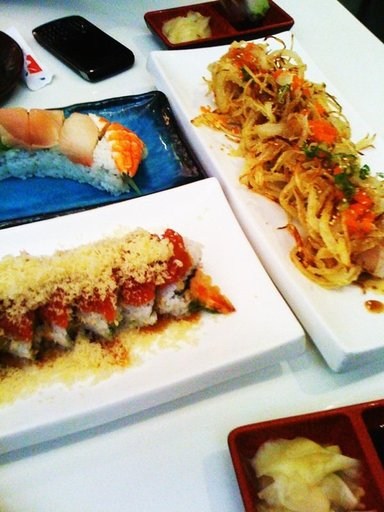

In [6]:
import random
from PIL import Image

random.seed(42)

# Visualize an image
train_images_paths = list(train_path.glob("*/*.jpg"))
rand_image_path = random.choice(train_images_paths)
rand_image_class = rand_image_path.parent.stem

img = Image.open(rand_image_path)

print(f"Image path: {rand_image_path}")
print(f"Image class: {rand_image_class}")
print(f"Image [height, width]: [{img.height}, {img.width}]")

img

Text(0.5, 1.0, 'Image class: sushi | Image shape: (512, 384, 3)')

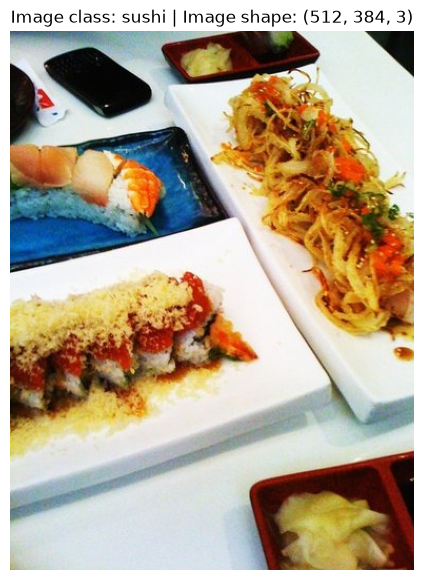

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Do the image visualization with matplotlib
image_nparray = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_nparray)
plt.axis(False)
plt.title(f"Image class: {rand_image_class} | Image shape: {image_nparray.shape}")

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [8]:
import torchvision
from torchvision import transforms
# 3.1 Transforming data with torchvision.transforms

In [9]:
# Write transform for turning images into tensors
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

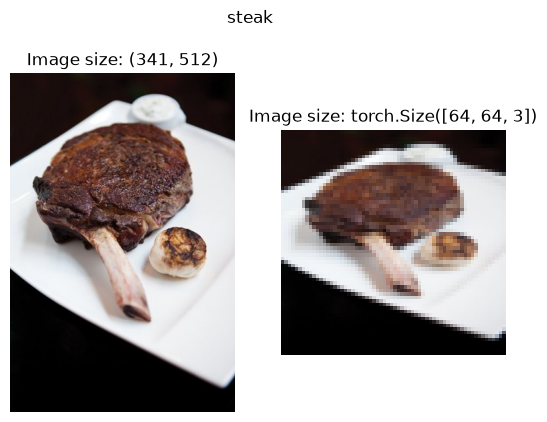

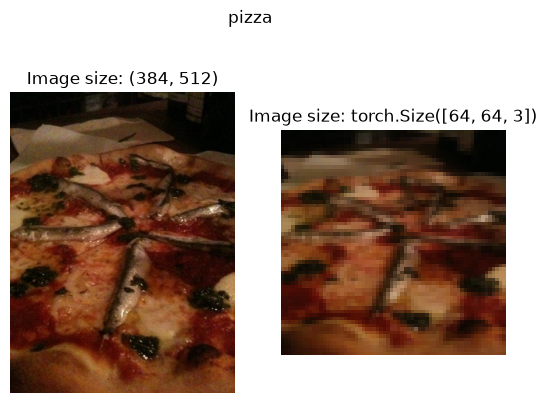

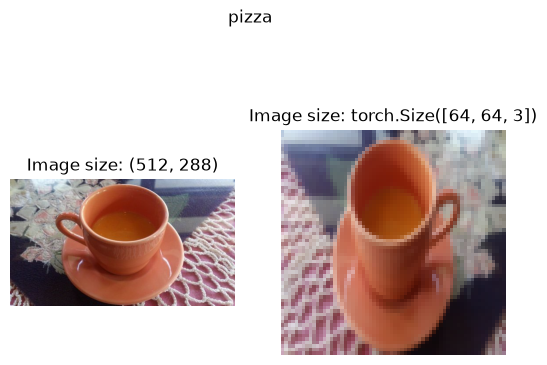

In [10]:
# Write a function to plot transformed images
def plot_transformed_images(image_paths: list[str], transform, n=3, seed=42):
    random.seed(seed)
    random_images_path = random.choices(image_paths, k=n)

    for path in random_images_path:
        with Image.open(path) as f:
            image_class = path.parent.stem
            
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Image size: {f.size}")
            ax[0].axis(False)
            
            transformed_img = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_img)
            ax[1].set_title(f"Image size: {transformed_img.shape}")
            ax[1].axis(False)
            
            fig.suptitle(image_class)

plot_transformed_images(train_images_paths, simple_transform)

### Load image data using `ImageFolder`

In [11]:
# Use ImageFolder to create dataset(s)
train_data = torchvision.datasets.ImageFolder(train_path, simple_transform)
test_data = torchvision.datasets.ImageFolder(test_path, simple_transform)

In [12]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [13]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [14]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [15]:
# Turn train and test Datasets into DataLoaders
BATCH_SIZE = 1

train_dataloader = torch.utils.data.DataLoader(train_data, 
                                               batch_size=BATCH_SIZE,
                                               shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_data, 
                                               batch_size=BATCH_SIZE,
                                               shuffle=False)

In [16]:
# How many batches of images are in our data loaders?
len(train_dataloader), len(test_dataloader)

(225, 75)

## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [17]:
class TinyVGGV0(nn.Module):
    def __init__(self, input_features, output_features, hidden_units):
        super().__init__()
        self.conv_layer_1 = nn.Sequential(
            # Padding 0 reduces 2 pixels per side: 64 -> 62
            nn.Conv2d(input_features, hidden_units, kernel_size=3, padding=0), 
            nn.ReLU(),
            # Padding 0 reduces 2 pixels per side: 62 -> 60
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            # MaxPooling with kernel_size=2 downsamples spatial dimensions by factor of 2: 60 -> 30
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_layer_2 = nn.Sequential(
            # Padding 0: 30 -> 28
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            # Padding 0: 28 -> 26
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            # MaxPool: 26 -> 13
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*13*13, out_features=output_features)
        )

    def forward(self, x):
        return self.classifier(self.conv_layer_2(self.conv_layer_1(x)))

model_0 = TinyVGGV0(input_features=3, # Image channels = 3 (RGB)
                    output_features=len(class_names), # Classes to predict
                    hidden_units=10).to(device)
model_0

TinyVGGV0(
  (conv_layer_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

## 4. Create training and testing functions for `model_0`.

In [18]:
a = torch.tensor([1., 2., 3., 4., 5., 6.])
b = torch.tensor([1, 2, 4, 4, 5, 6])
result = (a == b)
result.sum() / len(a)

tensor(0.8333)

In [19]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  
  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for X, y in dataloader:
    # Send data to target device
    X, y = X.to(device), y.to(device)
    # 1. Forward pass
    y_pred = model(X)
    y_pred_labels = torch.argmax(y_pred, dim=1)

    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad 
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumualte accuracy metric across all batches
    acc = torch.sum(y_pred_labels == y) / len(y)
    train_acc += acc.item()

  # Adjust metrics to get average loss and average accuracy per batch
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [20]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  
  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for X, y in dataloader:
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)
      y_pred_labels = torch.argmax(y_pred, dim=1)

      # 2. Calculuate and accumulate loss
      loss = loss_fn(y_pred, y)
      test_loss += loss.item()

      # Calculate and accumulate accuracy
      acc = torch.sum(y_pred_labels == y) / len(y)
      test_acc += acc.item()
    
  # Adjust metrics to get average loss and accuracy per batch
  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc

In [21]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model, 
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    
    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer. 

In [22]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), 
                             lr=0.001)

result_5_epochs = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1059 | train_acc: 0.3600 | test_loss: 1.0986 | test_acc: 0.3333
Epoch: 2 | train_loss: 1.0990 | train_acc: 0.3467 | test_loss: 1.0996 | test_acc: 0.3333
Epoch: 3 | train_loss: 1.0989 | train_acc: 0.3467 | test_loss: 1.1000 | test_acc: 0.3333
Epoch: 4 | train_loss: 1.0987 | train_acc: 0.3467 | test_loss: 1.1003 | test_acc: 0.3333
Epoch: 5 | train_loss: 1.0989 | train_acc: 0.3467 | test_loss: 1.1006 | test_acc: 0.3333


In [23]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = TinyVGGV0(input_features=3, # Image channels = 3 (RGB)
                    output_features=len(class_names), # Classes to predict
                    hidden_units=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), 
                             lr=0.001)

result_20_epochs = train(model=model_1,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=15)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0958 | train_acc: 0.3733 | test_loss: 1.0798 | test_acc: 0.4533
Epoch: 2 | train_loss: 1.0014 | train_acc: 0.5467 | test_loss: 0.9940 | test_acc: 0.4400
Epoch: 3 | train_loss: 0.9076 | train_acc: 0.5911 | test_loss: 1.0037 | test_acc: 0.5067
Epoch: 4 | train_loss: 0.9111 | train_acc: 0.6044 | test_loss: 1.0831 | test_acc: 0.4400
Epoch: 5 | train_loss: 0.9146 | train_acc: 0.5689 | test_loss: 0.9758 | test_acc: 0.4933
Epoch: 6 | train_loss: 0.8800 | train_acc: 0.5822 | test_loss: 0.9792 | test_acc: 0.4667
Epoch: 7 | train_loss: 0.8453 | train_acc: 0.6267 | test_loss: 1.0306 | test_acc: 0.5333
Epoch: 8 | train_loss: 0.8304 | train_acc: 0.6222 | test_loss: 1.0450 | test_acc: 0.4400
Epoch: 9 | train_loss: 0.7872 | train_acc: 0.6533 | test_loss: 1.0482 | test_acc: 0.5200
Epoch: 10 | train_loss: 0.7830 | train_acc: 0.6711 | test_loss: 1.0136 | test_acc: 0.5067
Epoch: 11 | train_loss: 0.8094 | train_acc: 0.6844 | test_loss: 1.0126 | test_acc: 0.5200
Epoch: 12 | train_l

In [24]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_2 = TinyVGGV0(input_features=3, # Image channels = 3 (RGB)
                    output_features=len(class_names), # Classes to predict
                    hidden_units=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), 
                             lr=0.001)

result_50_epochs = train(model=model_2,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=30)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0918 | train_acc: 0.3911 | test_loss: 1.0630 | test_acc: 0.3733
Epoch: 2 | train_loss: 0.9795 | train_acc: 0.5111 | test_loss: 1.0032 | test_acc: 0.4667
Epoch: 3 | train_loss: 0.8840 | train_acc: 0.6044 | test_loss: 1.0144 | test_acc: 0.4800
Epoch: 4 | train_loss: 0.8934 | train_acc: 0.5822 | test_loss: 1.0656 | test_acc: 0.4400
Epoch: 5 | train_loss: 0.8891 | train_acc: 0.5956 | test_loss: 1.0082 | test_acc: 0.4667
Epoch: 6 | train_loss: 0.8396 | train_acc: 0.6311 | test_loss: 0.9874 | test_acc: 0.5067
Epoch: 7 | train_loss: 0.8032 | train_acc: 0.6533 | test_loss: 1.0449 | test_acc: 0.5467
Epoch: 8 | train_loss: 0.7271 | train_acc: 0.6844 | test_loss: 1.0757 | test_acc: 0.5200
Epoch: 9 | train_loss: 0.6332 | train_acc: 0.7067 | test_loss: 1.0760 | test_acc: 0.4800
Epoch: 10 | train_loss: 0.6308 | train_acc: 0.7378 | test_loss: 1.1544 | test_acc: 0.5333
Epoch: 11 | train_loss: 0.6358 | train_acc: 0.7289 | test_loss: 1.1089 | test_acc: 0.4533
Epoch: 12 | train_l

It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [25]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_3 = TinyVGGV0(input_features=3,
                    output_features=len(class_names),
                    hidden_units=20).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer =  torch.optim.Adam(params=model_3.parameters(),
                              lr=0.001)

train(model_3, train_dataloader, test_dataloader, optimizer, loss_fn, epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1118 | train_acc: 0.3244 | test_loss: 1.0992 | test_acc: 0.4133
Epoch: 2 | train_loss: 1.0982 | train_acc: 0.3911 | test_loss: 1.0987 | test_acc: 0.3333
Epoch: 3 | train_loss: 1.0487 | train_acc: 0.5156 | test_loss: 1.0432 | test_acc: 0.4400
Epoch: 4 | train_loss: 0.9636 | train_acc: 0.5244 | test_loss: 0.9971 | test_acc: 0.4667
Epoch: 5 | train_loss: 0.8999 | train_acc: 0.6178 | test_loss: 1.1101 | test_acc: 0.4533
Epoch: 6 | train_loss: 0.8919 | train_acc: 0.5867 | test_loss: 0.9845 | test_acc: 0.4533
Epoch: 7 | train_loss: 0.8262 | train_acc: 0.6622 | test_loss: 1.0180 | test_acc: 0.5333
Epoch: 8 | train_loss: 0.8252 | train_acc: 0.5778 | test_loss: 1.0655 | test_acc: 0.5200
Epoch: 9 | train_loss: 0.7937 | train_acc: 0.6622 | test_loss: 1.0499 | test_acc: 0.4800
Epoch: 10 | train_loss: 0.7417 | train_acc: 0.6933 | test_loss: 1.0135 | test_acc: 0.5067
Epoch: 11 | train_loss: 0.7001 | train_acc: 0.7289 | test_loss: 1.0562 | test_acc: 0.5333
Epoch: 12 | train_l

{'train_loss': [1.11184856944614,
  1.0982226501570806,
  1.0487499988762041,
  0.9636425943755441,
  0.8998897856732624,
  0.8919364149744312,
  0.8262153778432144,
  0.8251715866675496,
  0.7937182913906873,
  0.7417050619671742,
  0.7001205798435128,
  0.6593352975158228,
  0.5914239263692354,
  0.5499714026421457,
  0.5432053416787483,
  0.4237592738434,
  0.4215364750176337,
  0.4205140117663662,
  0.3334213913875131,
  0.3363559508303701],
 'train_acc': [0.3244444444444444,
  0.39111111111111113,
  0.5155555555555555,
  0.5244444444444445,
  0.6177777777777778,
  0.5866666666666667,
  0.6622222222222223,
  0.5777777777777777,
  0.6622222222222223,
  0.6933333333333334,
  0.7288888888888889,
  0.7422222222222222,
  0.76,
  0.8044444444444444,
  0.8133333333333334,
  0.8533333333333334,
  0.8444444444444444,
  0.84,
  0.8844444444444445,
  0.8755555555555555],
 'test_loss': [1.099234824180603,
  1.0987005201975504,
  1.0432103860378266,
  0.9971476356188457,
  1.1101496740182242,
 

It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [26]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...") 
    zip_ref.extractall(image_path)

data\pizza_steak_sushi_20_percent directory exists.
Unzipping pizza, steak, sushi 20% data...


In [27]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\test'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\pizza'.
There are 0 directories and 58 images in 'data\pizza_steak_sushi_20_percent\test\steak'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\train'.
There are 0 directories and 154 images in 'data\pizza_steak_sushi_20_percent\train\pizza'.
There are 0 directories and 146 images in 'data\pizza_steak_sushi_20_percent\train\steak'.
There are 0 directories and 150 images in 'data\pizza_steak_sushi_20_percent\train\sushi'.


Excellent, we now have double the training and testing images... 

In [28]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

In [29]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((64, 64)),                                     
  transforms.ToTensor()
])

# Create datasets
train_data = torchvision.datasets.ImageFolder(root=train_data_20_percent_path,
                                             transform=simple_transform)
test_data = torchvision.datasets.ImageFolder(root=test_data_20_percent_path,
                                             transform=simple_transform)

# Create dataloaders
train_dataloader = torch.utils.data.DataLoader(dataset=train_data,
                                               batch_size=BATCH_SIZE,
                                               shuffle=True)
test_dataloader = torch.utils.data.DataLoader(dataset=test_data,
                                               batch_size=BATCH_SIZE,
                                               shuffle=False)

In [30]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_4 = TinyVGGV0(input_features=3,
                    output_features=len(class_names),
                    hidden_units=20).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer =  torch.optim.Adam(params=model_4.parameters(),
                              lr=0.001)

results = train(model_4, train_dataloader, test_dataloader, optimizer, loss_fn, epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1035 | train_acc: 0.3333 | test_loss: 1.0987 | test_acc: 0.3067
Epoch: 2 | train_loss: 1.1014 | train_acc: 0.3244 | test_loss: 1.0993 | test_acc: 0.3067
Epoch: 3 | train_loss: 1.0991 | train_acc: 0.3422 | test_loss: 1.0998 | test_acc: 0.3067
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.3422 | test_loss: 1.0998 | test_acc: 0.3067
Epoch: 5 | train_loss: 1.1070 | train_acc: 0.3467 | test_loss: 1.0991 | test_acc: 0.3000
Epoch: 6 | train_loss: 1.0799 | train_acc: 0.4178 | test_loss: 1.0477 | test_acc: 0.5400
Epoch: 7 | train_loss: 0.9905 | train_acc: 0.5533 | test_loss: 0.9529 | test_acc: 0.5800
Epoch: 8 | train_loss: 0.9374 | train_acc: 0.5933 | test_loss: 0.9675 | test_acc: 0.6200
Epoch: 9 | train_loss: 0.9358 | train_acc: 0.5756 | test_loss: 0.9313 | test_acc: 0.5600
Epoch: 10 | train_loss: 0.9031 | train_acc: 0.5867 | test_loss: 0.9301 | test_acc: 0.6000
Epoch: 11 | train_loss: 0.8940 | train_acc: 0.5889 | test_loss: 0.9425 | test_acc: 0.5533
Epoch: 12 | train_l

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction. 
* Does the model you trained in exercise 7 get it right? 
* If not, what do you think you could do to improve it?

In [34]:
image_path = data_path / 'steak-downloaded.jpg'
with Image.open(image_path) as f:
    image_tensor = simple_transform(f).unsqueeze(dim=0)

image_tensor.shape

torch.Size([1, 3, 64, 64])

In [37]:
pred_logits = model_4(image_tensor.to(device))
pred_probs = torch.softmax(pred_logits, dim=1)
pred_label = torch.argmax(pred_probs, dim=1)

print(f"Pred logits: {pred_logits}")
print(f"Pred probs: {pred_probs}")
print(f"Pred label: {class_names[pred_label.item()]}")

Pred logits: tensor([[-0.4950,  0.1514, -4.4597]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
Pred probs: tensor([[0.3416, 0.6520, 0.0065]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Pred label: steak
